In [393]:
import pandas as pd
import numpy as np
import openpyxl
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot  as plt
import seaborn as sns

In [392]:
# Load and Clean Pollinating Insect 
FILE = 'data/pollinating-insects.xlsx'

SHEETS = {
    'pollinators': '1',
    'bees': '3',
    'hoverflies': '5',
    'species': '7'   
}

xls = pd.ExcelFile(FILE)

# Worksheet 1
pollinators_df = pd.read_excel(xls, SHEETS['pollinators'], skiprows=3)
pollinators_df.columns = (pollinators_df.columns.str.strip().str.lower().str.replace(' ', '_'))
pollinators_df['year'] = pollinators_df['year'].astype('Int64') # Enforce Int data type 
pollinators_df = pollinators_df.dropna(subset=["year"]) # enforce datatype

pollinators_df = pollinators_df.rename(columns={
    "indicator_(mean_occupancy)": "pollinator_occupancy_index",
    "95%_credible_interval_minimum:_all_pollinators": "pollinator_lower_confidence_interval",
    "95%_credible_interval_maximum:_all_pollinators": "pollinator_upper_confidence_interval"
})

# Worksheet 2
bees_df = pd.read_excel(xls, SHEETS['bees'], skiprows=3)
bees_df.columns = (bees_df.columns.str.strip().str.lower().str.replace(' ', '_'))
bees_df['year'] = bees_df['year'].astype('Int64')
bees_df = bees_df.dropna(subset=["year"]) 


bees_df = bees_df.rename(columns={
    "indicator_(mean_occupancy):_wild_bees": "wild_bees_occupancy_index",
    "95%_credible_interval_minimum:_wild_bees": "wild_bees_lower_confidence_interval",
    "95%_credible_interval_maximum:_wild_bees": "wild_bees_upper_confidence_interval"
})

hoverflies_df = pd.read_excel(xls, SHEETS['hoverflies'], skiprows=3)
hoverflies_df.columns = (hoverflies_df.columns.str.strip().str.lower().str.replace(' ', '_'))
hoverflies_df['year'] = hoverflies_df['year'].astype('Int64') # Enforce Int data type 
hoverflies_df = hoverflies_df.dropna(subset=["year"]) # enforce datatype

hoverflies_df = hoverflies_df.rename(columns={
    "indicator_(mean_occupancy):_hoverflies": "hoverflies_occupancy_index",
    "95%_credible_interval_minimum:_hoverflies": "hoverflies_lower_confidence_interval",
    "95%_credible_interval_maximum:_hoverflies": "hoverflies_upper_confidence_interval"
})


In [391]:
# Load and Clean insects_wider_countryside

FILE = 'data/insects-wider-countryside.xlsx'

SHEETS = {
    'butterflies': '1'   
}

xls = pd.ExcelFile(FILE)

butterflies_df = pd.read_excel(xls, SHEETS['butterflies'], skiprows=6).iloc[:, 0:5]
butterflies_df.columns = (butterflies_df.columns.str.strip().str.lower().str.replace(' ', '_')) # fix columns 
butterflies_df['year'] = butterflies_df['year'].astype('Int64') # ensure its int data type been applied 
butterflies_df = butterflies_df.apply(pd.to_numeric, errors="coerce") # check numeric columns 
butterflies_df = butterflies_df.dropna(subset=["year"]) # drop NaN columns 
butterflies_df = butterflies_df.rename(columns={
    'unsmoothed_index' : 'butterfly_unsmoothed_index',
    'smoothed_index' : 'butterfly_smoothed_index',
    'lower_ci': 'butterfly_lower_ci', 
    'upper_ci': 'butterfly_upper_ci'
}) # fix semantics in columns 


In [390]:
# Load and Clean plants_wider_countryside
FILE = 'data/plants-wider-countryside.xlsx'
xlsx = pd.ExcelFile(FILE)
xlsx.sheet_names

SHEETS = {
    'plants_habitat': '1'   
}

plants_habitat_df = pd.read_excel(xlsx, SHEETS['plants_habitat'], skiprows=5)
plants_habitat_df.columns = (plants_habitat_df.columns.str.strip().str.lower().str.replace(' ', '_')) # fix columns 
plants_habitat_df['year'] = plants_habitat_df['year'].astype('Int64') # ensure its int data type been applied 
plants_habitat_df = plants_habitat_df.rename(columns={
    'habitat' : 'habitat_type',
    'unsmoothed_index' : 'habitat_index',
    'lower_95_ci': 'habitat_lower_ci', 
    'upper_95_ci': 'habitat_upper_ci'
})

# fix habitat types to 1 value per year
plants_habitat_yearly = (
    plants_habitat_df
    .groupby("year", as_index=False)
    .agg({
        "habitat_index": "mean",
        "habitat_lower_ci": "mean",
        "habitat_upper_ci": "mean"
    })
)

In [389]:
# Load and Clean habitat-connectivity
FILE = 'data/habitat-connectivity.xlsx'
xlsx = pd.ExcelFile(FILE)
xlsx.sheet_names


SHEETS = ({
    'birds_connectivity': '4',
    'habitats_greatbritain': '7'
})

birds_connectivity_df = pd.read_excel(xlsx, SHEETS['birds_connectivity'], skiprows=4)
birds_connectivity_df.columns = (birds_connectivity_df.columns.str.strip().str.lower().str.replace(' ', '_')) # fix columns 
birds_connectivity_df = birds_connectivity_df.rename(
    columns={"year_[note_1]": "year",
            "unsmoothed_index_[note_3]": "birds_unsmoothed_index",
             "smoothed_index": "birds_smoothed_index",
             "smoothed_index_95%_confidence_interval_lower_bound": "birds_ci_lower_bound",
             "smoothed_index_95%_confidence_interval_upper_bound": "birds_ci_upper_bound"
                    
})
birds_connectivity_df['year'] = birds_connectivity_df['year'].astype('Int64')

habitats_great_britain_df = pd.read_excel(xlsx, SHEETS['habitats_greatbritain'], skiprows=3)
habitats_great_britain_df.columns = (habitats_great_britain_df.columns.str.strip().str.lower().str.replace(' ', '_')) # fix columns 
habitats_great_britain_df = habitats_great_britain_df.rename(
    columns=lambda x: "avg_connectivity_value" if "mean_connectivity" in x else x
)
habitats_great_britain_df['year'] = habitats_great_britain_df['year'].astype('Int64')

# implement pivot table
habitats_pivot = habitats_great_britain_df.pivot_table(
    index='year', 
    columns='habitat_type', 
    values='avg_connectivity_value',
    aggfunc='mean'
).reset_index()
habitats_pivot.columns.name = None 
habitats_pivot.columns = [c.lower().replace(' ', '_').replace(',', '') for c in habitats_pivot.columns]

birds_connectivity_df.shape

(28, 5)

In [387]:
# Merge  master table 
# year is the common key across all datasets 
master_dataset_df  = (
    bees_df
    .merge(pollinators_df, on="year", how="outer")
    .merge(butterflies_df, on="year", how="outer")
    .merge(hoverflies_df, on="year", how="outer")
    .merge(plants_habitat_yearly, on="year", how="outer")
    .merge(birds_connectivity_df, on="year", how="outer")
    .merge(habitats_pivot, on="year", how="outer")
)
print("IMMEDIATELY AFTER MERGE:")
print(f"Shape: {master_dataset_df.shape}")
print(f"\nTotal NaN: {master_dataset_df.isna().sum().sum()}")

IMMEDIATELY AFTER MERGE:
Shape: (49, 23)

Total NaN: 341


In [385]:
# Step 2 Merge MasterDataset Clean till it goes to GA Algoritm 

master_dataset_df = master_dataset_df.apply(pd.to_numeric, errors='coerce') 
master_dataset_df = master_dataset_df.sort_values('year')  # sort the timeline is correct 
master_dataset_df.columns = master_dataset_df.columns.str.strip() # spacing 
master_dataset_df['year'] = master_dataset_df['year'].astype(int) # make sure the year is using int 

# dropped confidence intervals (ci) known as metadata and not useful 
cols_to_drop = [c for c in master_dataset_df.columns 
                if 'confidence' in c or 'ci' in c or 'credible' in c]
master_dataset_df = master_dataset_df.drop(columns=cols_to_drop)


master_dataset_df.to_csv('data/master_dataset.csv', index=False)  # saving it as a csv file 

print(f"Data ready for GA: {master_dataset_df.shape}")



Data ready for GA: (49, 11)


# Classification of the attributes table

Attibutes Name                     | Category   |  Data Type |  Role   | 
----------|----------|------|------|
year                               | Temporal   |  Integer   | Index   |  
wild_bees_occupancy_index          | Ecological |  Float64   | Target  |
pollinator_occupancy_index         | Ecological |  Float64   | Feature |
butterfly_unsmoothed_index         | Ecological |  Float64   | Feature |
butterfly_smoothed_index           | Ecological |  Float64   | Feature |
hoverflies_occupancy_index         | Ecological |  Float64   | Feature |
habitat_index                      | Landscape  |  Float64   | Feature |
birds_unsmoothed_index             | Ecological |  Float64   | Feature |
birds_smoothed_index               | Ecological |  Float64   | Feature |
broad-leaved_mixed_and_yew_woodland| Landscape  |  Float64   | Feature |
broad-leaved_mixed_and_yew_woodland| Landscape  |  Float64   | Feature |
neutral_grassland                  | Landscape  |  Float64   | Feature |
________________________________________________________________

In [383]:
# ----------------------------------
# Step 3 Genetic Algorithm (Year Alignment)
# -----------------------------------


df = master_dataset_df.copy()

TARGET_COL = "wild_bees_occupancy_index"
YEAR_COL = "year"

# All columns except 'year' are potential indicators/target for completeness
MODEL_COLS = [c for c in df.columns if c != YEAR_COL] 
FEATURE_COLS = [c for c in df.columns if c not in [YEAR_COL, TARGET_COL]]


# Setup Data Limit 
YEAR_MIN = int(master_dataset_df['year'].min())
YEAR_MAX = int(master_dataset_df['year'].max())
POSSIBLE_YEARS = list(range(YEAR_MIN, YEAR_MAX + 1))

# GA Parameters
POP_SIZE = 20
N_FEATURES = len(FEATURE_COLS)  
CHROMOSOME_LENGTH = N_FEATURES + 2   # Add +2 to the length for the two year genes 
N_GENERATIONS = 50
MIN_WINDOW_YEARS = 10


#Initalise population 
def init_population(pop_size):
    pop = []
    for _ in range(pop_size):
        # Year genes: large ints for modulo mapping
        year_genes = np.random.randint(0, 10000, size=2)
        # Feature genes: binary 0 or 1
        feature_genes = np.random.randint(0, 2, size=N_FEATURES)
        pop.append(np.concatenate([year_genes, feature_genes]))
    return pop


def decode_chromosome(chromosome):
    """
    Extract years and selected features 
    """
    start_idx = int(chromosome[0] % len(POSSIBLE_YEARS))
    end_idx = int(chromosome[1] % len(POSSIBLE_YEARS))
    s_yr = int(POSSIBLE_YEARS[min(start_idx, end_idx)])
    e_yr = int(POSSIBLE_YEARS[max(start_idx, end_idx)])
    
    # Features
    feature_bits = chromosome[2:]
    selected_features = [FEATURE_COLS[i] for i, bit in enumerate(feature_bits) if bit == 1]
    
    return s_yr, e_yr, selected_features
    

def evaluate_individual(chromosome, df):   
    """
    Alignment
    """
    s_yr, e_yr, selected_features = decode_chromosome(chromosome)
    window_years = (e_yr - s_yr + 1)

    # 1. Penalty for tiny windows / no features
    if window_years < MIN_WINDOW_YEARS or len(selected_features) == 0:
        return 0.0

    # 2. Filter data to the proposed window
    window_df = df[(df[YEAR_COL] >= s_yr) & (df[YEAR_COL] <= e_yr)]
    if len(window_df) == 0:
        return 0.0 

    # 3. Calculate Completeness of SELECTED features + TARGET
    cols_to_check = selected_features + [TARGET_COL]
    total_cells = len(window_df) * len(cols_to_check)
    non_missing_cells = window_df[cols_to_check].notna().sum().sum()
    
    completeness = non_missing_cells / total_cells

    # 4. Reject windows with excessive missingness (50% missing)
    if completeness < 0.5:
        return 0.0

    # Fitness = Volume of data {Rows} multiplied by its quality {Completeness}
    fitness = len(window_df) * completeness
    
    return float(fitness)

def mutate(chromosome, mutation_rate=0.1):
    mutated = chromosome.copy() 
    for i in range(len(mutated)):
        if np.random.rand() < mutation_rate:
            if i < 2: # Nudge year genes
                mutated[i] += np.random.randint(-500, 501)
            else: # Flip feature bits
                mutated[i] = 1 - mutated[i]
    return mutated

def crossover(parent1, parent2):
    point = np.random.randint(1, len(parent1))
    return np.concatenate((parent1[:point], parent2[point:]))
    
    
# implenting elitism 
def elitist_selection(population_ranked, retain_ratio=0.2):
    retain_len = max(2, int(len(population_ranked) * retain_ratio))
    return [chrom.copy() for chrom, score in population_ranked[:retain_len]]

# ----Run GA Loop---
population = init_population(POP_SIZE)
best_overall_score = -np.inf
best_overall_chrom = None

print("Starting Genetic Algorithm")
print("=" * 50)
      
for gen in range(N_GENERATIONS):
    scores = np.array([evaluate_individual(ch, df) for ch in population])
    population_ranked = sorted(zip(population, scores), key=lambda x: x[1], reverse=True)

    if population_ranked[0][1] > best_overall_score:
        best_overall_score = population_ranked[0][1]
        best_overall_chrom = population_ranked[0][0].copy()

    elites = elitist_selection(population_ranked, retain_ratio=0.2)
    new_population = [e.copy() for e in elites]

    
    while len(new_population) < POP_SIZE:
       idx1, idx2 = np.random.choice(len(elites), 2, replace=False)
       p1, p2 = elites[idx1], elites[idx2]
       child = crossover(p1, p2)
       new_population.append(mutate(child, mutation_rate=0.1))
    
    population = new_population


    if gen % 10 == 0: 
        s_imp, e_tmp, feats = decode_chromosome(best_overall_chrom)
        print(f"Gen {gen:02d} | Fitness: {best_overall_score:.2f} | Window: {s_imp}-{e_tmp} | Feats: {len(feats)}")
        

final_start, final_end, final_feats = decode_chromosome(best_overall_chrom)
print("-" * 50)
print(f"Optimal Alignment: {final_start} - {final_end}")
print(f"VIABLE FEATURES: {len(final_feats)} identified")
# print(f"Selected Features: {len(final_feats)}")
print(f"Selected features: {final_feats}")
aligned_df = df[(df[YEAR_COL] >= final_start) & (df[YEAR_COL] <= final_end)].copy()
aligned_df = aligned_df.sort_values(YEAR_COL)

# ---------------------------------------------
# Step 4 Addtionally Cleaning After Optimisation
# ---------------------------------------------

keep_cols = [YEAR_COL, TARGET_COL] + final_feats
aligned_df = aligned_df[keep_cols].copy()
cols_to_fill = [TARGET_COL] + final_feats

# 2. fills the gaps inside the only  selected window
aligned_df[cols_to_fill] = aligned_df[cols_to_fill].interpolate(method="linear").bfill().ffill()


print(f"The Complete Pre-processing Complete. Data ready for next stage: SVR ML Model")

Starting Genetic Algorithm
Gen 00 | Fitness: 24.43 | Window: 1978-2009 | Feats: 6
Gen 10 | Fitness: 39.80 | Window: 1978-2018 | Feats: 4
Gen 20 | Fitness: 40.33 | Window: 1978-2018 | Feats: 2
Gen 30 | Fitness: 40.33 | Window: 1978-2018 | Feats: 2
Gen 40 | Fitness: 47.00 | Window: 1976-2024 | Feats: 2
--------------------------------------------------
Optimal Alignment: 1976 - 2024
VIABLE FEATURES: 2 identified
Selected features: ['butterfly_unsmoothed_index', 'butterfly_smoothed_index']
The Complete Pre-processing Complete. Data ready for next stage: SVR ML Model


In [377]:
#-----------------------------------------------------
# Dataset 2 without GA: All selected feature selection
#-----------------------------------------------------

aligned_df_without_ga = df[(df[YEAR_COL] >= final_start) & (df[YEAR_COL] <= final_end)].copy()
aligned_df_without_ga = aligned_df_without_ga.sort_values(YEAR_COL)

# All features 
all_features = [col for col in df.columns if col not in [YEAR_COL]]  # All except year
keep_cols_without_ga = [YEAR_COL] + all_features
aligned_df_without_ga = aligned_df_without_ga[keep_cols_without_ga].copy()

# 2. fills the all features iterpolate
cols_to_fill_without_ga = all_features
aligned_df_without_ga[cols_to_fill_without_ga] = (
    aligned_df_without_ga[cols_to_fill_without_ga]
        .apply(pd.to_numeric, errors="coerce")  # optional but usually needed
        .interpolate(method="linear", limit_direction="both")
        .bfill()
        .ffill()
)

print("\nDataset WITHOUT GA feature selection:")
print(f"  Time window: {final_start} - {final_end} (same as WITH GA)")
print(f"  Rows (years): {aligned_df_without_ga.shape[0]}")
print(f"  Columns total: {aligned_df_without_ga.shape[1]}")


Dataset WITHOUT GA feature selection:
  Time window: 1976 - 2024 (same as WITH GA)
  Rows (years): 49
  Columns total: 11


In [376]:

#----------------------------------------------
# Solution 1 SVR GA with Feature Selection 
#----------------------------------------------

#Target Variable
y_svr = aligned_df['wild_bees_occupancy_index']

# With GA feature selection 
X_svr_ga = aligned_df[final_feats]


print("="*50)
print("DATA SETUP")
print("="*50)
print(f"Target variable: {y.name}")
print(f"WITH GA features ({X_svr_ga.shape[1]}): {list(X_svr_ga.columns)}")
print(f"Sample size: n={len(y)}")


# Split before scaling - Train-test split (80/20)
X_with_train, X_with_test, y_train, y_test = train_test_split(
    X_with_scaled, 
    y, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

print(f"\nTrain set: n={len(X_with_train)}")
print(f"Test set: n={len(X_with_test)}")


# Scale after Features 
scaler_with = StandardScaler()
X_with_train_scaled = scaler_with.fit_transform(X_with_train)
X_with_test_scaled = scaler_with.transform(X_with_test)

#----------------------------------------------
# Helper function for Comprehensive Evalutation  
#----------------------------------------------
def evaluate_svr(model, X_train, X_test, y_train, y_test, label="Model"):
     # Cross-validation on training set
    cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_mae = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    cv_rmse = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    cv_mape = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error')
    
    # Train on full training set
    model.fit(X_train, y_train)
    
    # Test set predictions
    y_pred = model.predict(X_test)
    
    # Test set metrics
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mape = mean_absolute_percentage_error(y_test, y_pred)
    
    results = {
        'label': label,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_mae_mean': -cv_mae.mean(),
        'cv_mae_std': cv_mae.std(),
        'cv_rmse_mean': -cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std(),
        'cv_mape': -cv_mape.mean(),
        'cv_mape_std': cv_mape.std(),
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_mape': test_mape
    }
    
    return results, model

def print_results(results):
    print(f"\n{results['label']}:")
    print(f"  Cross-Validation 5 folds (n={len(X_with_train)}):")
    print(f"    R² = {results['cv_r2_mean']:.4f} (±{results['cv_r2_std']:.4f})")
    print(f"    MAE = {results['cv_mae_mean']:.4f} (±{results['cv_mae_std']:.4f})")
    print(f"    RMSE = {results['cv_rmse_mean']:.4f} (±{results['cv_rmse_std']:.4f})")
    print(f"    MAPE = {results['cv_mape']*100:.2f}% (±{results['cv_mape_std']*100:.2f})")
    print(f"  Test Set (n={len(X_with_test)}):")
    print(f"    R² = {results['test_r2']:.4f}")
    print(f"    MAE = {results['test_mae']:.4f}")
    print(f"    RMSE = {results['test_rmse']:.4f}")
    print(f"    MAPE = {results['test_mape']*100:.2f}%")

#---------------------------
# SVR Baseline GA selection  
#---------------------------

print("\n" + "="*50)
print("SVR WITH GA FEATURE SELECTION (Baseline SVR)")
print("="*50)

svr_with_baseline = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

results_with_baseline, _ = evaluate_svr(
    svr_with_baseline, 
    X_with_train_scaled, 
    X_with_test_scaled, 
    y_train, 
    y_test,
    label="Baseline (C=1.0, epsilon=0.1)"
)
# resuls of baseline SVR
print_results(results_with_baseline)

# Hyperparamer Tuning 
print("\n--- Hyperparameter Tuning ---")
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.5],
    'gamma': ['scale', 'auto']
}

grid_with = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_with.fit(X_with_train, y_train)

print(f"\nparameters: {grid_with.best_params_}")

# results of tuned model 
results_with_tuned, svr_with_tuned = evaluate_svr(
    grid_with.best_estimator_, 
    X_with_train, 
    X_with_test, 
    y_train, 
    y_test,
    label=f"Tuned {grid_with.best_params_}"
)
print_results(results_with_tuned)

DATA SETUP
Target variable: wild_bees_occupancy_index
WITH GA features (2): ['butterfly_unsmoothed_index', 'butterfly_smoothed_index']
Sample size: n=49

Train set: n=39
Test set: n=10

SVR WITH GA FEATURE SELECTION (Baseline SVR)

Baseline (C=1.0, epsilon=0.1):
  Cross-Validation 5 folds (n=39):
    R² = -0.3990 (±0.7029)
    MAE = 3.7704 (±1.2695)
    RMSE = 5.3724 (±1.7823)
    MAPE = 3.61% (±1.10)
  Test Set (n=10):
    R² = 0.0028
    MAE = 5.8611
    RMSE = 8.5823
    MAPE = 5.22%

--- Hyperparameter Tuning ---
Fitting 5 folds for each of 32 candidates, totalling 160 fits

parameters: {'C': 100, 'epsilon': 0.01, 'gamma': 'auto'}

Tuned {'C': 100, 'epsilon': 0.01, 'gamma': 'auto'}:
  Cross-Validation 5 folds (n=39):
    R² = -0.0018 (±0.6130)
    MAE = 3.3716 (±0.8650)
    RMSE = 4.2435 (±1.0253)
    MAPE = 3.31% (±0.82)
  Test Set (n=10):
    R² = 0.8974
    MAE = 2.1274
    RMSE = 2.7534
    MAPE = 1.98%


In [375]:

#----------------------------------------------
# Solution 2 SVR without Feature Selection 
#---------------------------------------------- 
YEAR_COL = "year"
TARGET_COL = "wild_bees_occupancy_index"

df_wo = aligned_df_without_ga   
all_features = [c for c in df_wo.columns if c not in [YEAR_COL, TARGET_COL]]
X_without_ga = df_wo[all_features]
y = df_wo[TARGET_COL]

print("="*50)
print("DATA SETUP")
print("="*50)
print(f"Target variable: {y.name}")
print(f"WITHOUT GA features (Excluding target_variable and year) ({X_without_ga.shape[1]}): {list(X_without_ga.columns)}")
print(f"Sample size: n={len(y)}")


# split first 
X_without_train, X_without_test, y_train, y_test = train_test_split(
    X_without_ga, 
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nTrain set: n={len(X_without_train)}")
print(f"Test set: n={len(X_without_test)}")

#Scale after splt for train only
scaler_without = StandardScaler()
X_without_train_scaled = scaler_without.fit_transform(X_without_train)
X_without_test_scaled = scaler_without.transform(X_without_test)  


#------------------------------------
# BaseLine SVR (all features selected)  
#------------------------------------
print("\n--- Baseline SVR ---")
print("="*50)
svr_without_selection = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
results_without_baseline, _ = evaluate_svr(
    svr_without_selection, 
    X_without_train_scaled, 
    X_without_test_scaled, 
    y_train, 
    y_test,
    label="Baseline C=1.0, epsilon=0.1, gamma='scale'"
)

print_results(results_without_baseline)

#-------------------------------------
# Hyperparameter Tuning  (without GA)  
#------------------------------------
print("\n--- Hyperparameter Tuning ---")
print("Using same parameter grid as Solution 1 for fair comparison")

grid_without = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_without.fit(X_without_train, y_train)

print(f"\nBest parameters: {grid_without.best_params_}")

results_without_tuned, svr_without_tuned = evaluate_svr(
    grid_without.best_estimator_, X_without_train, X_without_test, y_train, y_test,
    label=f"Tuned {grid_without.best_params_}"
)
print_results(results_without_tuned)


DATA SETUP
Target variable: wild_bees_occupancy_index
WITHOUT GA features (Excluding target_variable and year) (9): ['pollinator_occupancy_index', 'butterfly_unsmoothed_index', 'butterfly_smoothed_index', 'hoverflies_occupancy_index', 'habitat_index', 'birds_unsmoothed_index', 'birds_smoothed_index', 'broad-leaved_mixed_and_yew_woodland', 'neutral_grassland']
Sample size: n=49

Train set: n=39
Test set: n=10

--- Baseline SVR ---

Baseline C=1.0, epsilon=0.1, gamma='scale':
  Cross-Validation 5 folds (n=39):
    R² = -0.1798 (±0.6325)
    MAE = 3.4747 (±1.3044)
    RMSE = 4.9927 (±1.9549)
    MAPE = 3.32% (±1.13)
  Test Set (n=10):
    R² = 0.0773
    MAE = 5.5336
    RMSE = 8.2556
    MAPE = 4.92%

--- Hyperparameter Tuning ---
Using same parameter grid as Solution 1 for fair comparison
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto'}

Tuned {'C': 10, 'epsilon': 0.01, 'gamma': 'auto'}:
  Cross-Validation 5 fold

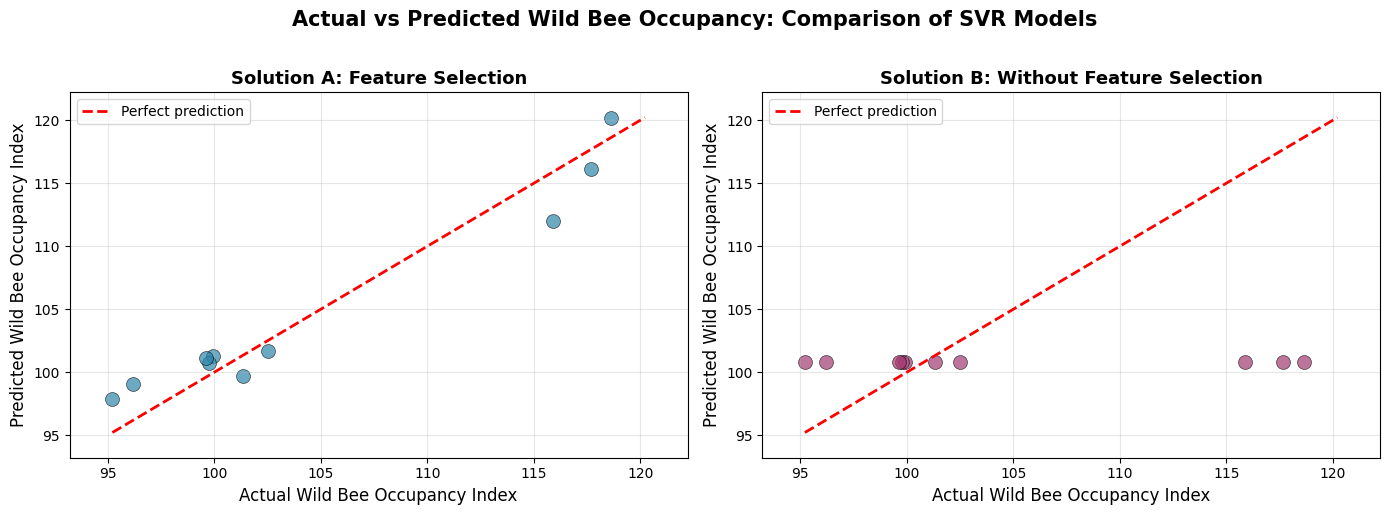


 Saved: actual_vs_predicted_comparison.png


In [374]:

#-------------------------------------
# Visualisation: Actual vs predicted 
#------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate common axis limits for fair comparison
min_val = min(y_test.min(), y_pred_with_ga.min(), y_pred_without_ga.min())
max_val = max(y_test.max(), y_pred_with_ga.max(), y_pred_without_ga.max())

# GA
axes[0].scatter(y_test, y_pred_with_ga, alpha=0.7, s=100, color='#2E86AB', edgecolors='black', linewidth=0.5)
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlim(min_val - 2, max_val + 2)
axes[0].set_ylim(min_val - 2, max_val + 2)
axes[0].set_xlabel('Actual Wild Bee Occupancy Index', fontsize=12)
axes[0].set_ylabel('Predicted Wild Bee Occupancy Index', fontsize=12)
axes[0].set_title(f'Solution A: Feature Selection', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# RIGHT: WITHOUT GA
axes[1].scatter(y_test, y_pred_without_ga, alpha=0.7, s=100, color='#A23B72', edgecolors='black', linewidth=0.5)
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlim(min_val - 2, max_val + 2)
axes[1].set_ylim(min_val - 2, max_val + 2)
axes[1].set_xlabel('Actual Wild Bee Occupancy Index', fontsize=12)
axes[1].set_ylabel('Predicted Wild Bee Occupancy Index', fontsize=12)
axes[1].set_title(f'Solution B: Without Feature Selection', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Wild Bee Occupancy: Comparison of SVR Models',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved: actual_vs_predicted_comparison.png")

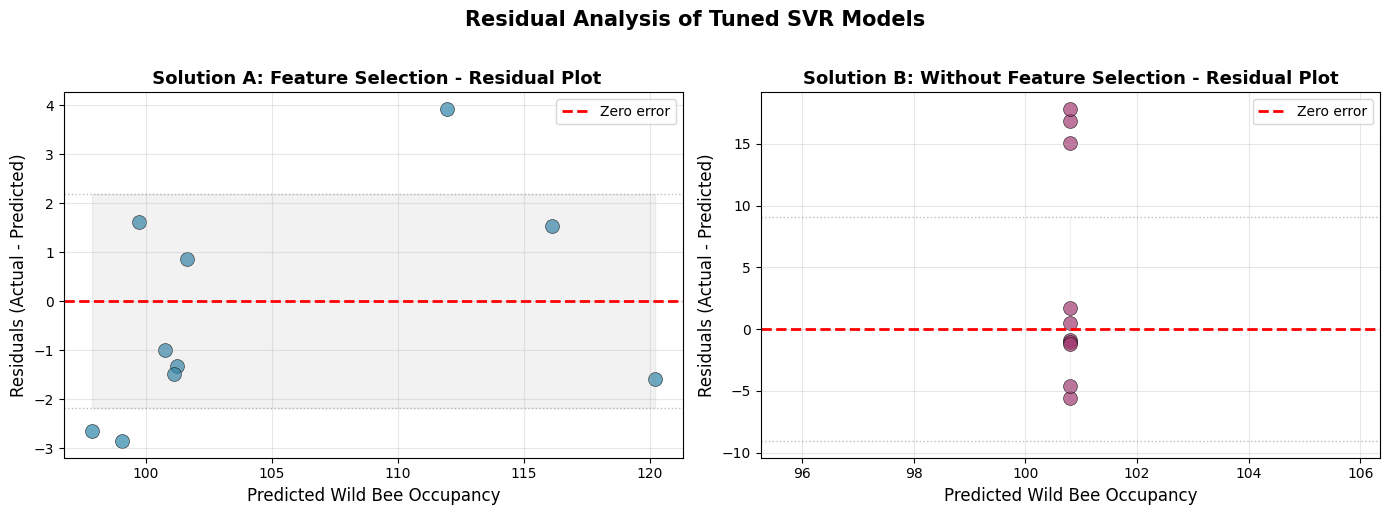


 Saved: residual_plot_comparison.png


In [373]:
# #-------------------------------------
# Visualisation: Resifual Plot 
#------------------------------------


residuals_with_ga = y_test - y_pred_with_ga
residuals_without_ga = y_test - y_pred_without_ga

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WITH GA residuals
axes[0].scatter(y_pred_with_ga, residuals_with_ga, alpha=0.7, s=100, 
                color='#2E86AB', edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0].set_xlabel('Predicted Wild Bee Occupancy', fontsize=12)
axes[0].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0].set_title(' Solution A: Feature Selection - Residual Plot', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

std_with = residuals_with_ga.std()
axes[0].axhline(y=std_with, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[0].axhline(y=-std_with, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[0].fill_between([y_pred_with_ga.min(), y_pred_with_ga.max()], 
                      -std_with, std_with, alpha=0.1, color='gray')

axes[1].scatter(y_pred_without_ga, residuals_without_ga, alpha=0.7, s=100, 
                color='#A23B72', edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[1].set_xlabel('Predicted Wild Bee Occupancy', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Solution B: Without Feature Selection - Residual Plot', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

std_without = residuals_without_ga.std()
axes[1].axhline(y=std_without, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1].axhline(y=-std_without, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1].fill_between([y_pred_without_ga.min(), y_pred_without_ga.max()], 
                      -std_without, std_without, alpha=0.1, color='gray')

plt.suptitle('Residual Analysis of Tuned SVR Models', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('residual_plot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved: residual_plot_comparison.png")
